# Workload characterization

This notebook describes the four workloads used in the Greenfilling campaign. We use the same job groups that were used to select these workloads:

- a **narrow-short job** requests at most 1% of the platform and runs for at most 2 hours;
- a **wide job** requests at least 10% of the platform.

A job can belong to neither group. These are not general small/medium/large categories. We compare two ways of describing each group: **how many jobs** it contains and **how much work** it represents. Work is measured in node-seconds: nodes requested × execution time. This matters because mean slowdown counts every job once, regardless of how much work it does.

In [5]:
from pathlib import Path
import sys

import pandas as pd


def find_repository_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / 'analysis' / 'shift_ceiling_results.py').exists():
            return candidate
    raise FileNotFoundError(
        'Run this notebook from inside the experimental-artifacts checkout'
    )


ROOT = find_repository_root(Path.cwd().resolve())
ANALYSIS_DIR = ROOT / 'analysis'
FIGURE_DIR = ANALYSIS_DIR / 'figures'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import workload_characterization_analysis as wca

pd.set_option('display.max_columns', 120)
wca.configure_plot_style()

ROOT, FIGURE_DIR

(PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures'))

## Load and classify replay jobs

We include only replay jobs—the jobs whose schedules we analyze later. Context jobs only recreate the queue at the start of a simulation. Execution time comes from each job's Batsim profile and the platform speed, not from its requested time limit (*walltime*).

In [6]:
jobs, thresholds = wca.load_jobs()
print(f'Replay jobs: {len(jobs):,}')
display(thresholds)

Replay jobs: 23,931


,platform_nodes,narrow_max_nodes,short_max_runtime_hours,wide_min_nodes
workload,,,,
mustang_stress,1600,16,2.0,160
mustang_slack,1600,16,2.0,160
trinity_stress,9408,94,2.0,941
trinity_slack,9408,94,2.0,941


## Counts and shares

The table reports two percentages for each group:

- **Job share:** jobs in the group ÷ all replay jobs.
- **Work share:** node-seconds in the group ÷ node-seconds of all replay jobs.

A group can have a high job share but a low work share.

In [7]:
summary = wca.summarize_jobs(jobs)
display(wca.format_summary(summary))

,Replay jobs,Narrow-short jobs,Narrow-short jobs [%],Narrow-short node-seconds [%],Wide jobs,Wide jobs [%],Wide node-seconds [%]
workload,,,,,,,
Mustang — Stress,5089,3199,62.86,0.21,235,4.62,58.15
Mustang — Slack,10683,4803,44.96,0.83,272,2.55,50.14
Trinity — Stress,3537,2300,65.03,0.07,524,14.81,86.54
Trinity — Slack,4622,3329,72.03,0.09,563,12.18,84.76


### Initial interpretation

Narrow-short jobs make up about **45–72% of jobs**, depending on the workload. Yet they account for only **0.07–0.83% of node-seconds**.

Wide jobs show the opposite pattern: only **2.5–14.8% of jobs**, but **50–87% of node-seconds**.

This difference matters for later results. Mean bounded slowdown gives each job equal weight. A short job can have a large slowdown if it waits much longer than it runs, so a strong effect from narrow-short jobs would be expected. Environmental impact may instead be more sensitive to the few wide jobs that do most of the work. These counts describe the workloads; they do not yet tell us how Greenfilling schedules them.

## Visual comparison

The left panel shows job share; the right shows work share. Bars are side by side because narrow-short and wide do not include every job. They should not be expected to add to 100%.

[PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/workload_narrow_short_and_wide_shares.pdf'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/workload_narrow_short_and_wide_shares.png')]

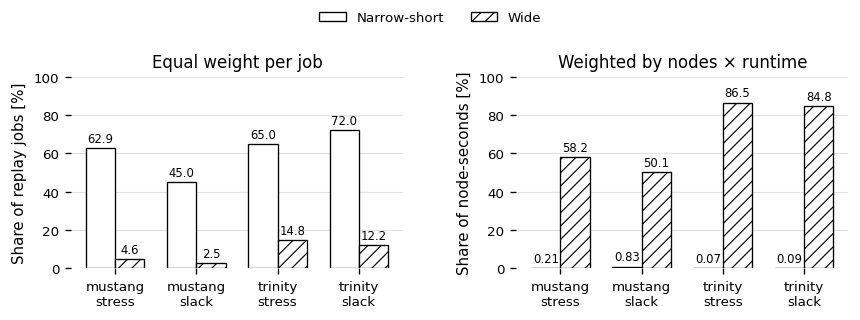

In [8]:
fig, _axes = wca.plot_shares(summary)
figure_paths = wca.export_figure(fig, FIGURE_DIR)
figure_paths

## Takeaway

Job count and work tell different stories. Narrow-short jobs are common but account for little work; wide jobs are rare but account for most work. The contrast is strongest in Trinity. The [slowdown analysis](greenfilling_slowdown_by_class.ipynb) follows up by comparing the same jobs under EASY and Greenfilling: which groups wait longer, and which groups raise the mean slowdown?